<table>
        <td>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="400"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue"> Conceptos Machine Learning </p> Clasificación </p> Curva ROC </FONT>         </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Machine Learning </p></tp>
            <tp><p style="font-size:115%;text-align:center">Diplomado 2026-1</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>

Veamos el ejemplo con el conjunto diabetes

## <FONT SIZE=4 COLOR="blue"> 1.1 Librerías de trabajo </FONT>

In [2]:
# Manipulación de data.frames
import pandas as pd
import numpy as np

# Librerías para Gráficos
import matplotlib.pyplot as plt
import seaborn           as sns
import plotly.express    as px

# Librerías para datos de entrenamiento y prueba
from sklearn.model_selection    import train_test_split

# Para preprocesamiento
from sklearn.preprocessing      import StandardScaler, MinMaxScaler

# Para aplicar k-nearest neiborg / logística
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import RandomForestClassifier
from sklearn.svm                import SVC

# Métricas de evaluación
from sklearn.metrics            import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics            import accuracy_score, precision_score, recall_score, f1_score
from imblearn.metrics           import specificity_score

# selección de características
from sklearn.feature_selection import RFE

# Optimización de hiperparámetros
from sklearn.model_selection    import GridSearchCV, RandomizedSearchCV

# Para ignorar los warnings
import warnings
warnings.filterwarnings("ignore")

## <FONT SIZE=4 COLOR="blue"> 1.2 Contexto del problema </FONT>

 En este caso intentaremos predecir a qué categoría corresponde un conjunto de datos.

En términos generales, seremos mucho más precisos si tenemos que modelar el comportamiento de una categoría que de una variable continua, por lo que veremos que muchas veces, incluso los problemas de predecir variables numéricas se pueden discretizar y convertir en problemas de clasificación.

En este caso, veremos un caso típico de un problema de clasificación. Queremos predecir si una integrante de una muestra que representa a una población, tiene diabetes. Queremos hacer esto a partir de múltiples variables que tenemos de cada uno de los pacientes:

- ***Pregnancies***: Número de embarazos que ha tenido en su vida
- ***Glucose***: Nivel de concentración de glucosa en sangre
- ***BloodPressure***: Presión arterial
- ***SkinThikness***: Espesor de piel a la altura del triceps
- ***Insulin***: Respuesta a dosis de insulina en 2 horas
- ***BMI***: Índice de masa corporal
- ***DiabetesPedigreeFunction***: Presencia de diabetes en ascendencia directa
- ***Age***: Edad del paciente
- ***Outcome***: Variable que queremos predecir:
   - $1$ : Tiene diabetes
   - $0$ : No tiene diabetes



## <FONT SIZE=4 COLOR="blue"> 1.3 Importar los datos </FONT>

Vamos a traer los datos del GitHub de la siguiente manera.

Lo primero que haremos es importar los datos que están en el siguiente link o pueden ser descargados de la página de Kaggle.

In [3]:
# cargar los datos
diabetes= pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/master/diabetes.csv")

In [4]:
# cabeza de los datos
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Vamos a hacer una función de evaluación de los modelos

In [20]:
def evaluacion_modelo(modelo, X_train, y_train, X_test, y_test, nombre_modelo = "modelo",graficar = True):
  # definir las predicciones en conjuntos de train y test
  y_pred_train = modelo.predict(X_train)
  y_pred_test  = modelo.predict(X_test)
  # matrices de confusión
  if graficar :
    # Calcular matrices de confusión
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_test = confusion_matrix(y_test, y_pred_test)
    # ejes para gráficas
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # matriz de confusión en train
    sns.heatmap(pd.DataFrame(cm_train),                # data.frame
                  annot=True,                          # colocar números de las cajitas
                  annot_kws = {'size':20},             # tamaño de la letra
                  cmap="YlOrRd",                       # color de la letra 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu'
                  fmt='g',                             # para que salgan los número no : notación científica
                  ax=axes[0])
    axes[0].set_title(f'Matriz de Confusión - Train-{nombre_modelo}', fontsize=14)
    axes[0].set_xlabel('Predicciones')
    axes[0].set_ylabel('Valores Reales')
    # matriz de confusión en test
    sns.heatmap(pd.DataFrame(cm_test),
              annot=True,
              fmt='g',
              cmap='YlOrRd',
              annot_kws={'size':20},
              ax=axes[1])
    axes[1].set_title(f'Matriz de Confusión - Test-{nombre_modelo}', fontsize=14)
    axes[1].set_xlabel('Predicciones')
    axes[1].set_ylabel('Valores Reales')
    plt.tight_layout()
    plt.show()
  # metricas en train
  metrics=["accuracy", "recall" , "specificity", "precision", "f1"]
  # valores
  values_train = [accuracy_score(y_train,y_pred_train),
          recall_score(y_train,y_pred_train),
          specificity_score(y_train,y_pred_train),
          precision_score(y_train,y_pred_train),
          f1_score(y_train,y_pred_train)]
  values_test = [accuracy_score(y_test,y_pred_test),
          recall_score(y_test,y_pred_test),
          specificity_score(y_test,y_pred_test),
          precision_score(y_test,y_pred_test),
          f1_score(y_test,y_pred_test)]

  df = pd.DataFrame({f"{nombre_modelo}_train" : values_train,
                      f"{nombre_modelo}_test" : values_test}, index = metrics)
  return df


In [21]:
# 1. definir variables
# variables predictoras
X = diabetes.drop("Outcome", axis=1)
# variable objetivo
y = diabetes.Outcome

# 2. train y test
X_train, X_test, y_train, y_test = train_test_split(X,                        # variables predictoras
                                                    y,                        # variable de respuesta
                                                    stratify = y,             # estratificar la muestra
                                                    random_state = 123,         # semilla para que al ejecutar siempre de igual
                                                    test_size = 0.3)          # tamaño del conjunto de prueba

# 3. escalar los datos
# esta es la función para escalar los datos
escalar = StandardScaler()
# escalar tanto el X_train como el X_test.
X_train_s = escalar.fit_transform(X_train)
X_test_s = escalar.transform(X_test)

**Modelo_log**

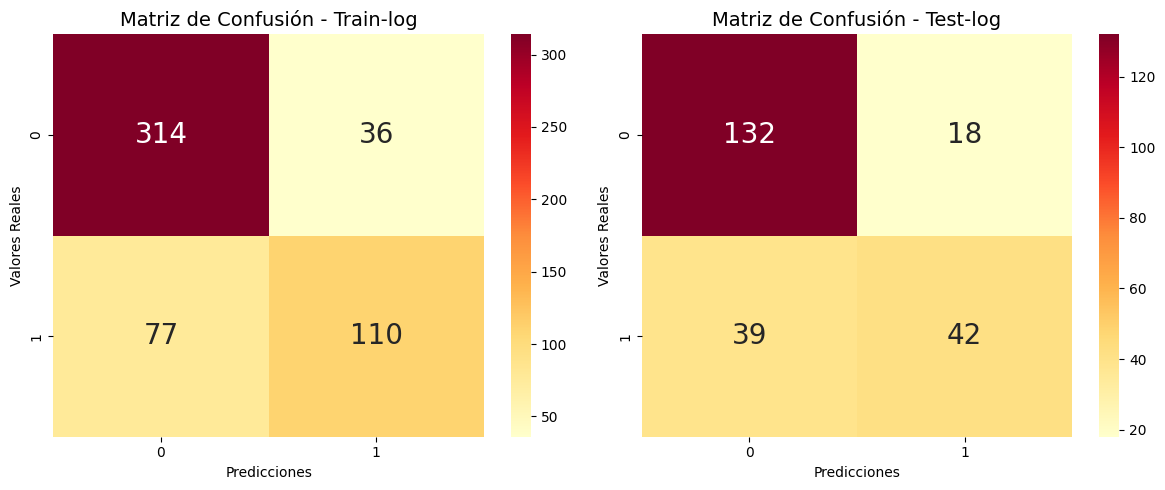

,log_train,log_test
accuracy,0.789572,0.753247
recall,0.588235,0.518519
specificity,0.897143,0.880000
precision,0.753425,0.700000
f1,0.660661,0.595745


In [22]:
modelo_log = LogisticRegression(random_state=123)
modelo_log.fit(X_train_s, y_train)
evaluacion_log = evaluacion_modelo(modelo_log, X_train_s, y_train, X_test_s, y_test, nombre_modelo = "log")
evaluacion_log


**Modelo_knn**

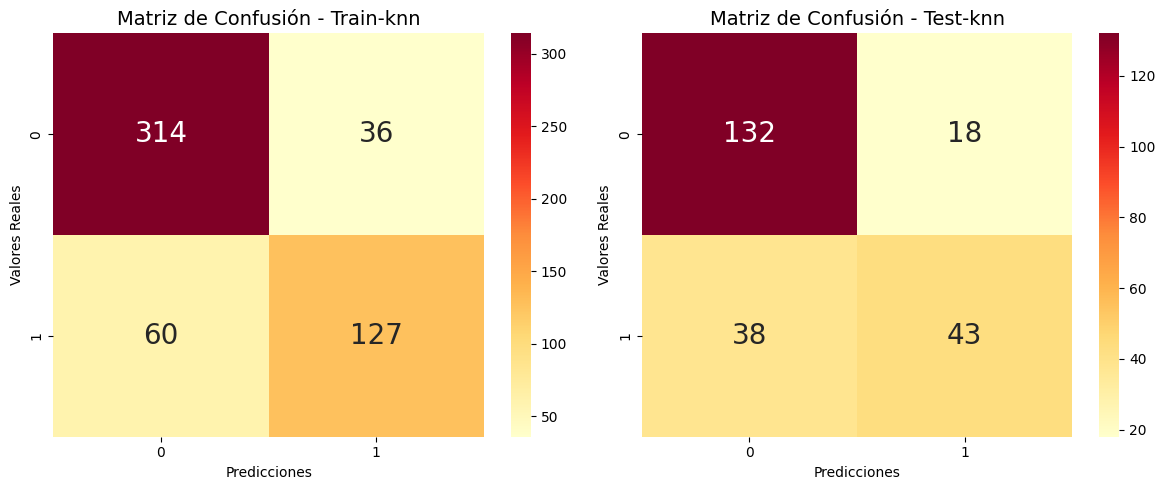

,knn_train,knn_test
accuracy,0.821229,0.757576
recall,0.679144,0.530864
specificity,0.897143,0.880000
precision,0.779141,0.704918
f1,0.725714,0.605634


In [23]:
modelo_knn = KNeighborsClassifier()
modelo_knn.fit(X_train_s, y_train)
evaluacion_knn = evaluacion_modelo(modelo_knn, X_train_s, y_train, X_test_s, y_test, nombre_modelo = "knn")
evaluacion_knn

**Modelo de árboles completo**

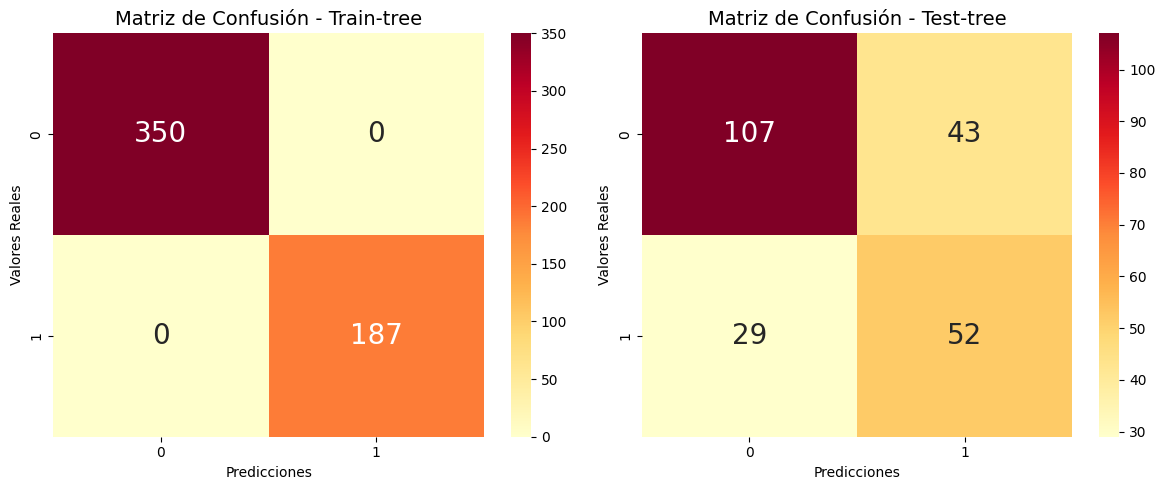

,tree_train,tree_test
accuracy,1.0,0.688312
recall,1.0,0.641975
specificity,1.0,0.713333
precision,1.0,0.547368
f1,1.0,0.590909


In [24]:
modelo_tree = DecisionTreeClassifier()
modelo_tree.fit(X_train, y_train)
evaluacion_tree = evaluacion_modelo(modelo_tree, X_train, y_train, X_test, y_test, nombre_modelo = "tree")
evaluacion_tree

**Modelo SVC**

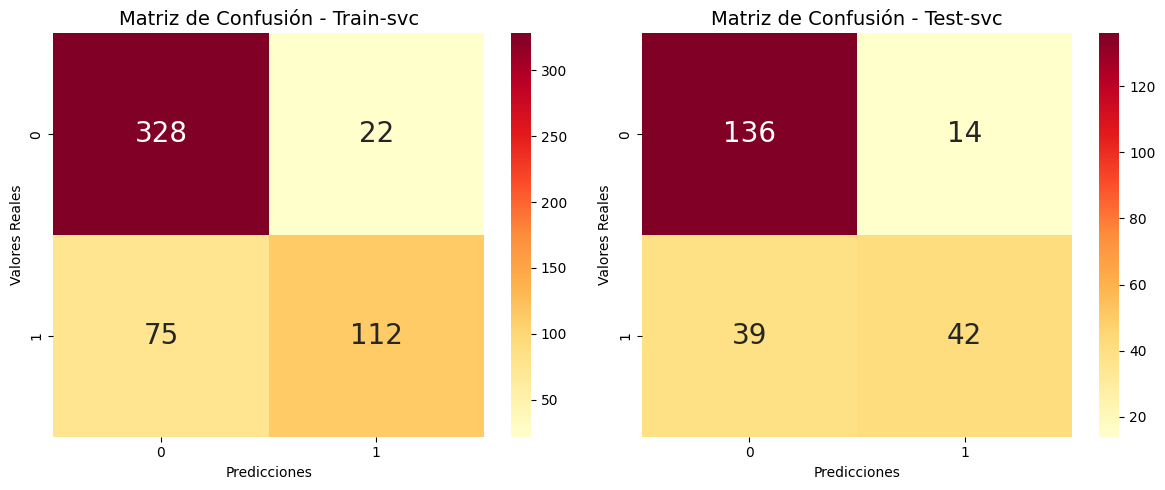

,svc_train,svc_test
accuracy,0.819367,0.770563
recall,0.598930,0.518519
specificity,0.937143,0.906667
precision,0.835821,0.750000
f1,0.697819,0.613139


In [25]:
modelo_svc = SVC()
modelo_svc.fit(X_train_s, y_train)
evaluacion_svc = evaluacion_modelo(modelo_svc, X_train_s, y_train, X_test_s, y_test, nombre_modelo = "svc")
evaluacion_svc

**Modelo Random Forest**

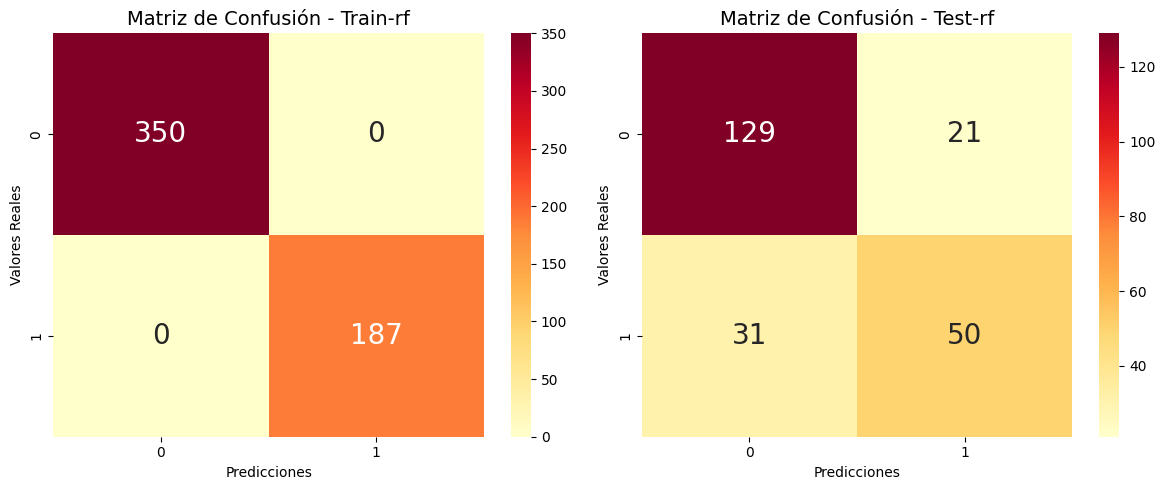

,rf_train,rf_test
accuracy,1.0,0.774892
recall,1.0,0.617284
specificity,1.0,0.860000
precision,1.0,0.704225
f1,1.0,0.657895


In [26]:
modelo_rf = RandomForestClassifier()
modelo_rf.fit(X_train, y_train)
evaluacion_rf = evaluacion_modelo(modelo_rf, X_train, y_train, X_test, y_test, nombre_modelo = "rf")
evaluacion_rf

**Resumen**

In [27]:
# pegar los eva en un solo dataframe
metricas_total = pd.concat([evaluacion_knn, evaluacion_log, evaluacion_tree, evaluacion_svc, evaluacion_rf], axis = 1)
metricas_total

,knn_train,knn_test,log_train,log_test,tree_train,tree_test,svc_train,svc_test,rf_train,rf_test
accuracy,0.821229,0.757576,0.789572,0.753247,1.0,0.688312,0.819367,0.770563,1.0,0.774892
recall,0.679144,0.530864,0.588235,0.518519,1.0,0.641975,0.598930,0.518519,1.0,0.617284
specificity,0.897143,0.880000,0.897143,0.880000,1.0,0.713333,0.937143,0.906667,1.0,0.860000
precision,0.779141,0.704918,0.753425,0.700000,1.0,0.547368,0.835821,0.750000,1.0,0.704225
f1,0.725714,0.605634,0.660661,0.595745,1.0,0.590909,0.697819,0.613139,1.0,0.657895


# <FONT SIZE=5 COLOR="purple"> 3. Curva ROC (Receiver operating characteristic) </FONT>

- *ROC* es el acrónimo de Receiver Operating Characteristics (característica operativa del receptor) y fue desarrollada en el campo de la ingeniería electrónica para medir la detección de objetos enemigos en el campo de batalla usando los radades durante la segunda guerra mundial. Fue la base para la TDS-Teoría de Detección de Señales.

- Sus aplicaciones trascendieron más allá del campo militar en áreas como la medicina, la epidemiología y en la investigación, etc.

- La curva ROC se aplica para evaluar algoritmos de *machine learning* y hacer comparación del rendimiento de estos.

- Formalmente, la ***curva ROC*** es la representación gráfica de la razón o proporción de verdaderos positivos (TPR = True positive rate) frente a la razón o proporción de falsos positivos (FPR = False positive rate) según se varía el umbral de discriminación (valor a partir del cual decidimos que un caso es un positivo).

- La curva *ROC* nos dice qué tan bueno puede distinguir el modelo entre dos cosas, por ejemplo, si un paciente tiene cáncer o no. Mejores modelos pueden distinguir con precisión entre los dos, mientras que un modelo pobre tendrá dificultades para distinguir entre los dos.

Supongamos que tenemos un modelo que predice si un paciente tiene cáncer o no. Teniendo en cuenta la matriz de confusión:

In [28]:
# para hacer la curva ROC
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

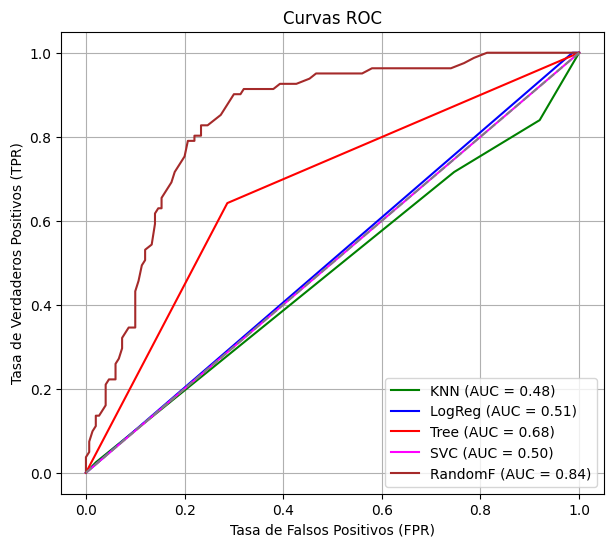

In [29]:
fpr_test_knn, tpr_test_knn, _ = roc_curve(y_test, modelo_knn.predict_proba(X_test)[:,1])
fpr_test_log, tpr_test_log, _ = roc_curve(y_test, modelo_log.predict_proba(X_test)[:,1])
fpr_test_tree, tpr_test_tree, _ = roc_curve(y_test, modelo_tree.predict_proba(X_test)[:,1])
fpr_test_svc, tpr_test_svc, _ = roc_curve(y_test, modelo_svc.decision_function(X_test))
fpr_test_rf, tpr_test_rf, _ = roc_curve(y_test, modelo_rf.predict_proba(X_test)[:,1])

# AUC
auc_test_knn = roc_auc_score(y_test, modelo_knn.predict_proba(X_test)[:,1])
auc_test_log = roc_auc_score(y_test, modelo_log.predict_proba(X_test)[:,1])
auc_test_tree = roc_auc_score(y_test, modelo_tree.predict_proba(X_test)[:,1])
auc_test_svc = roc_auc_score(y_test, modelo_svc.decision_function(X_test))
auc_test_rf = roc_auc_score(y_test, modelo_rf.predict_proba(X_test)[:,1])


# Gráfica curva ROC
plt.figure(figsize=(7,6))
plt.plot(fpr_test_knn, tpr_test_knn, color='green', label=f'KNN (AUC = {auc_test_knn:.2f})')
plt.plot(fpr_test_log, tpr_test_log, color='blue', label=f'LogReg (AUC = {auc_test_log:.2f})')
plt.plot(fpr_test_tree, tpr_test_tree, color='red', label=f'Tree (AUC = {auc_test_tree:.2f})')
plt.plot(fpr_test_svc, tpr_test_svc, color='magenta', label=f'SVC (AUC = {auc_test_svc:.2f})')
plt.plot(fpr_test_rf, tpr_test_rf, color='brown', label=f'RandomF (AUC = {auc_test_rf:.2f})')

# Línea diagonal (azar)
plt.plot([0,1], [0,1], color='gray', linestyle='--')

# Detalles del gráfico
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curvas ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()